### Assignment 2: APIs, Data Formats, Databases, and EDA

### Task 0: Course Project Dataset Exploration

a) The data I have chosen is a real-time lightning strike data. The data is downloaded from Kaggle

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vivektiwari020801/real-time-lightning-strikes")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\sandr\.cache\kagglehub\datasets\vivektiwari020801\real-time-lightning-strikes\versions\640


In [5]:
import pandas as pd
import os

print(os.listdir(path))
lightningdata = pd.read_csv(os.path.join(path, "lightning.csv"))
lightningdata.head()

['lightning.csv']


,time,lat,lon,region,mds,mcg,status
0,1765963807212409088,28.194713,-96.328267,1,7609,200,22
1,1765963809812001280,27.517726,-95.683990,1,8074,238,17
2,1765963814515200000,27.276969,-97.171758,1,10556,212,20
3,1765963814718639360,26.555502,-97.758053,1,9205,218,19
4,1765963814768915200,26.572890,-97.731561,1,6208,215,17


b) My dataset describes real-time lightning strikes. It contains of the variables

    time: which describes the exakt moment of lightning strike, in the unit Unix  timestamp

    
    lat: latitude

    
    lon: longitude 

    
    region: geographic region identifier (1-14)

    
    mds: minimum detectable signal (measurement for signal strength)

    
    mcg: maximum circular gap (how close the signal-receiving stations are from  the strike) (the information from this one was not on kaggle but I found it here https://www.mdpi.com/2073-4433/14/10/1507)

    
    status: there is no clear description of this one (when I gave AI the site from where the owner of the data got the information from, AI suggested that it might be how many lighting dectector stations that registered the lightning strike)

I did create another column that gives the date and time normally so it would be easier to understand, called time_date.

The data consists of 7 variables, which I have just mentioned and it spans over a week of time from 17 December to 23 December 2025. It contains 742543 rows. I am going to try to do some predictions of lightning strikes. Because the time span for the data is quite short I cannot do long-term forecasting with it. Instead I was thinking of trying to predict strike intensity based on the location of the strike or trying to find hotspots by clustering. I wanted to choose this data because I thought it would be more interesting with lightning strike data from the whole world instead of country-specific data. 
 

c) Descriptive statistics and visualizations of the data

In [8]:
#creating another column since the time is in Unix timestamps 
lightningdata["time_date"] = pd.to_datetime(lightningdata["time"], unit="ns")

print("Summary Statistics")
lightningdata.describe().round(2)

Summary Statistics


,time,lat,lon,region,mds,mcg,status,time_date
count,7.425430e+05,742543.00,742543.00,742543.00,742543.00,742543.00,742543.00,742543
mean,1.766247e+18,19.10,-35.82,5.98,8875.19,224.25,48.59,2025-12-20 16:09:45.419842816
min,1.765961e+18,-46.69,-179.40,1.00,382.00,41.00,9.00,2025-12-17 08:45:05.413384704
25%,1.766140e+18,18.59,-94.97,2.00,6355.00,203.00,21.00,2025-12-19 10:23:50.105729024
50%,1.766209e+18,22.60,-78.79,4.00,8727.00,235.00,28.00,2025-12-20 05:37:13.409732864
75%,1.766389e+18,31.86,10.76,12.00,11448.00,251.00,48.00,2025-12-22 07:44:20.433736960
max,1.766529e+18,71.49,179.93,14.00,14999.00,270.00,565.00,2025-12-23 22:33:54.758820864
std,1.508314e+14,19.98,86.79,4.53,3214.08,36.46,60.88,NaN


The the regions are only defined by number in the data, so I printed them on a map


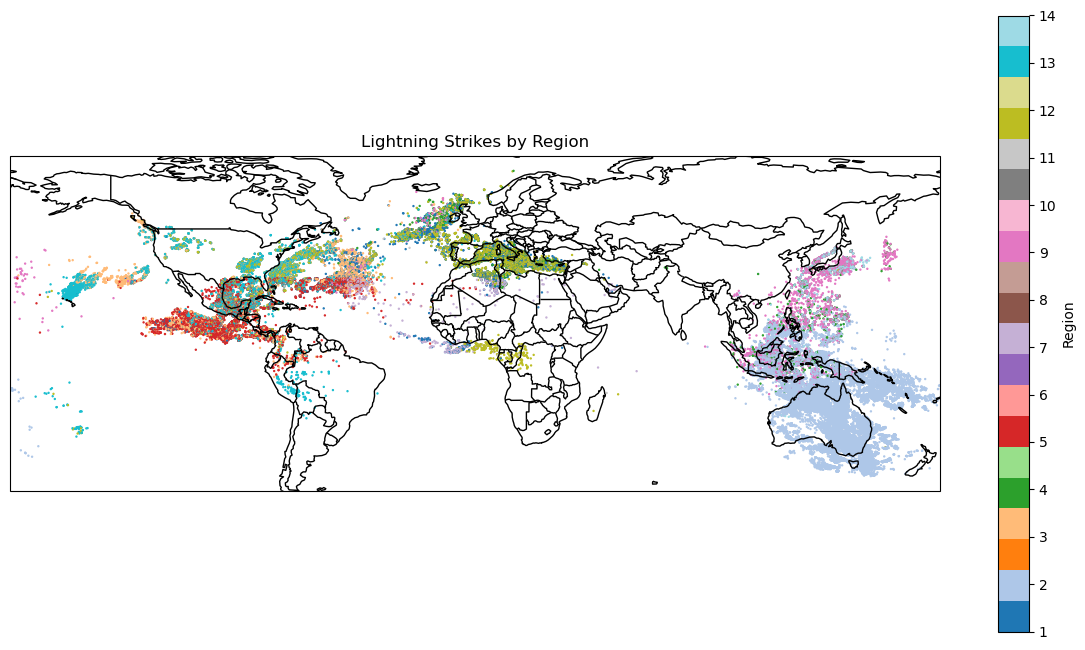

In [9]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

print("The the regions are only defined by number in the data, so I printed them on a map")

fig, ax = plt.subplots(figsize=(15, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

scatter = ax.scatter(lightningdata["lon"], lightningdata["lat"],
                     c=lightningdata["region"], cmap="tab20", s=0.5, transform=ccrs.PlateCarree(),
                    vmin=1, vmax=14)
cbar = fig.colorbar(scatter, ax = ax, label='Region')
cbar.set_ticks(range(1, 15))  # tick for every region 1-14
cbar.set_ticklabels(range(1, 15))
plt.title("Lightning Strikes by Region")
plt.show()

In [10]:
#medium latitude and longitude per region, essentially the center of each region,
#I will use this later in the project to look more closely into the location of the re
lightningdata.groupby("region")[["lat", "lon"]].mean().round(2)

,lat,lon
region,,
1,32.83,-30.01
2,-23.21,140.51
3,24.77,-87.78
4,35.19,29.93
5,20.55,-92.32
7,24.80,-20.74
9,27.13,101.91
11,35.14,-14.85
12,33.57,-22.46


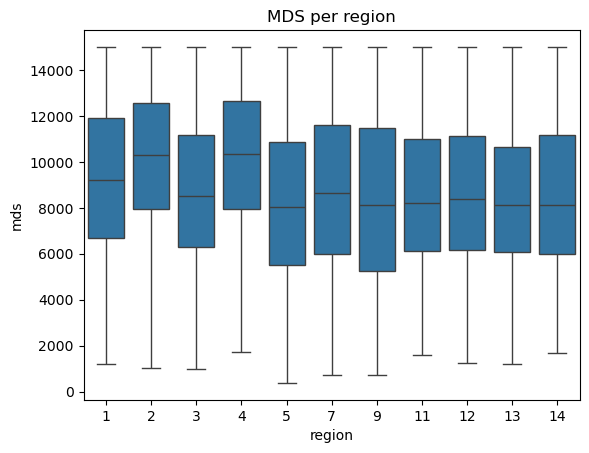

In [11]:
import seaborn as sns
sns.boxplot(data = lightningdata, x = "region", y = "mds")
plt.title("MDS per region");
#this is the signal strength per region

### Task 1: Setting up an API key and .env file 

In [13]:
from dotenv import load_dotenv
import os

load_dotenv(r"C:\Users\sandr\OneDrive\Documents\Hanken\MSc\Python Programming\assignments\assignment 2\.env")

api_key = os.environ.get("MS_API_KEY")

if api_key:
    print(f"Key loaded: {api_key[:5]}...")
else:
    print("ERROR: MS_API_KEY NOT FOUND.")

Key loaded: c1ed7...


### Task 2: Retrieving Data From MarketStack

In [15]:
#a) Retrieving eod data for FAANG stocks 
import requests
import pandas as pd
import json

url = "http://api.marketstack.com/v1/eod"
params = {
    "access_key": api_key,
    "symbols": "META,AAPL,AMZN,NFLX,GOOG",
    "date_from": "2026-03-01",
    "date_to": "2026-03-31"
}
response = requests.get(url, params=params)

# API limit reached, loading from saved data instead
with open("exports/stockdata.json", "r") as f:
    stockdata = json.load(f)

#b) Converting to JSON
dfjson = pd.DataFrame(stockdata["data"])
display(dfjson.head())

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31T00:00:00+0000
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31T00:00:00+0000
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31T00:00:00+0000
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31T00:00:00+0000


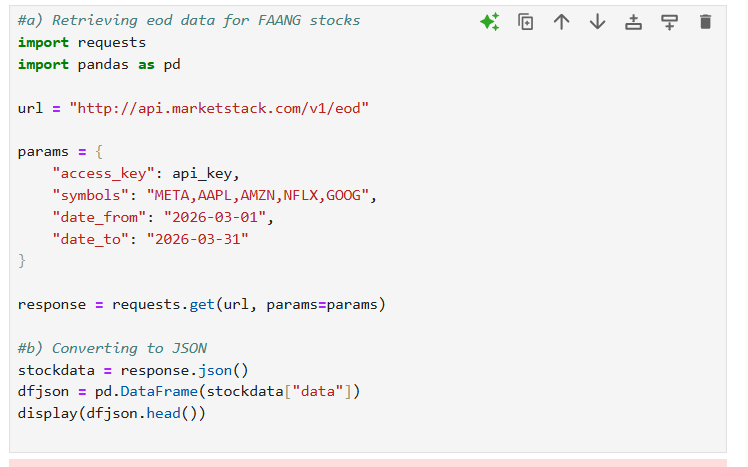
My free API key usage reached its limit when I was going through and finalizing this assignment. I retrieved the data from where it was saved in task 4 so that it would run. I also included a screenshot of what my assignment looked like before the API was reached. I happened to struggle with an error in this part that made have to rerun this part many times before I managed to fix it.

In [17]:
#c) Summary statistics for

stocksummarystats = dfjson.groupby("symbol")["close"].describe() #describe automatically gives summary statistics
print("Summary Statitistics for Closing Prices:")
display(stocksummarystats)

Summary Statitistics for Closing Prices:


,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,20.0,253.9735,4.843451,246.63,250.0750,252.855,258.0650,262.52
AMZN,20.0,210.1385,4.856686,199.34,207.6375,210.005,213.2800,218.94
GOOG,20.0,297.2825,11.232111,273.14,289.4925,301.185,305.8000,309.41
META,20.0,611.0580,41.315247,525.72,593.4750,614.695,645.4925,667.73
NFLX,20.0,94.8445,2.518470,90.92,93.2325,94.530,96.3475,99.17


### Task 3: Visualizing Stock Data

a)


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31


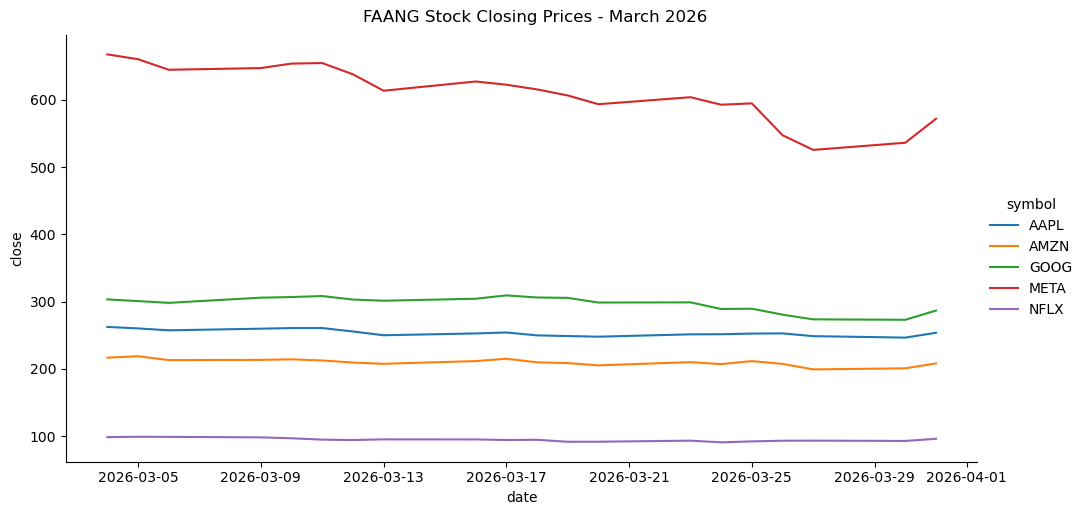

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

#a) 
print("a)")
#adjusting the date column to make it look neater in the chart
dfjson["date"] = pd.to_datetime(dfjson["date"]).dt.date
display(dfjson.head())

stock_line = sns.relplot(
            data = dfjson,
            x = "date", y = "close", 
            hue = "symbol", kind = "line", 
            height=5, aspect=2
)
stock_line.figure.suptitle("FAANG Stock Closing Prices - March 2026", y=1.02); 

b)


Text(0, 0.5, 'Return in %')

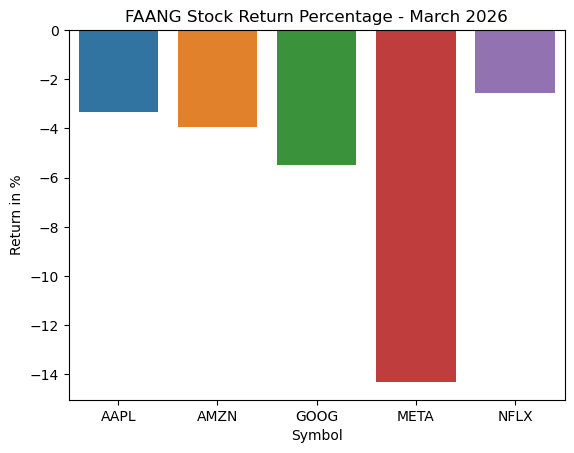

In [20]:
#b) 
print("b)")

#calculating the percentage returns 
returns = dfjson.groupby("symbol").apply(
    lambda g: (g.sort_values("date")["close"].iloc[-1] - 
               g.sort_values("date")["close"].iloc[0]) /
                g.sort_values("date")["close"].iloc[0]*100,
                include_groups=False
).reset_index()
returns.columns = ["symbol", "return_%"]

#plot 
sns.barplot(data = returns, x = "symbol", y = "return_%", hue = "symbol")
plt.title("FAANG Stock Return Percentage - March 2026")
plt.xlabel("Symbol")
plt.ylabel("Return in %")


c)


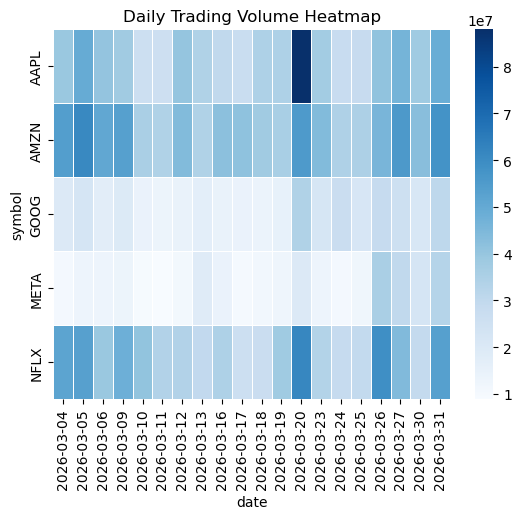

In [21]:
#c) Heatmap 
print("c)")

#changing the data into pivot data because that is necessary for the heatmap and making the dates neater
dfjson["date"] = pd.to_datetime(dfjson["date"]).dt.date
volume_pivot = dfjson.pivot_table(index = "symbol", columns = "date", values = "volume")


sns.heatmap(volume_pivot, cmap = "Blues", fmt = "0.f", linewidths = 0.5)
plt.title("Daily Trading Volume Heatmap")
plt.show()

### Task 4: Exporting and Importing Data

In [23]:
import json
import os

#a) Export JSON data from task 2 
os.makedirs("exports", exist_ok = True)

with open("exports/stockdata.json", "w") as f:
        json.dump(stockdata, f, indent=2)

print("The JSON data is exported into a file and placed in the folder: exports!")

#b) Export DataFrame From task 2b)
dfjson.to_csv("exports/stockdata.csv", index = False)

print("The DataFrame is now exported into a csv file and stored in the folder: exports!")


#c)Load back both the data from the files 

#JSON
with open("exports/stockdata.json", "r") as f: 
    stockdatajson = json.load(f)
df_json = pd.DataFrame(stockdatajson["data"])
print("JSON Data")
display(df_json.head())

#CSV 
stockdatacsv = pd.read_csv("exports/stockdata.csv")
print("CSV Data")
display(stockdatacsv.head())

#both the JSON and CSV are printing the same values as Task 2

The JSON data is exported into a file and placed in the folder: exports!
The DataFrame is now exported into a csv file and stored in the folder: exports!
JSON Data


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31T00:00:00+0000
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31T00:00:00+0000
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31T00:00:00+0000
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31T00:00:00+0000


CSV Data


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31


### Task 5: Querying the Northwind Database

In [25]:
import sqlite3

#a) Connecting to the database and listing all tables it contains
print("a)")
connection = sqlite3.connect("northwind.db")
db = connection.cursor()

db.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = db.fetchall()

for table in tables: 
    print(table[0])

#b) Products with a unit price above 30
print("b)")
query1 = """
SELECT ProductName, UnitPrice, UnitsInStock
FROM Products
WHERE UnitPrice > 30
"""

df_products = pd.read_sql_query(query1, connection)
display(df_products)

#c) DataFrame joining different variables 
print("c)")
query2 = """
SELECT c.CompanyName,
       o.OrderID,
       o.OrderDate,
       o.ShipCountry,
       od.UnitPrice * od.Quantity AS LineTotal
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN 'Order Details' od ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany'
"""
df_germany = pd.read_sql_query(query2, connection)
display(df_germany)


connection.close()

a)
Categories
sqlite_sequence
CustomerCustomerDemo
CustomerDemographics
Customers
Employees
EmployeeTerritories
Order Details
Orders
Products
Regions
Shippers
Suppliers
Territories
b)


,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.00,6
1,Mishi Kobe Niku,97.00,29
2,Ikura,31.00,31
3,Queso Manchego La Pastora,38.00,86
4,Alice Mutton,39.00,0
5,Carnarvon Tigers,62.50,42
6,Sir Rodney's Marmalade,81.00,40
7,Gumbär Gummibärchen,31.23,15
8,Schoggi Schokolade,43.90,49
9,Rössle Sauerkraut,45.60,26


c)


,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0
...,...,...,...,...,...
80668,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,864.0
80669,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,735.0
80670,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,75.0
80671,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,500.0


### Task 6: Visualizing Northwind Data

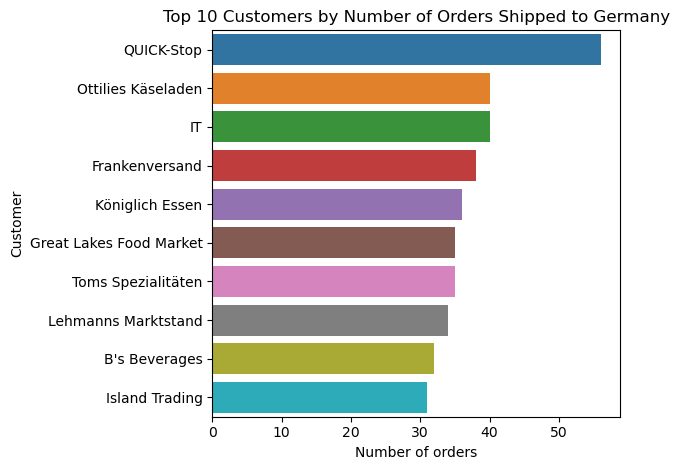

In [27]:
#a)

#counting the number of orders per customers 
orders_per_customer = df_germany.groupby("CompanyName")["OrderID"].nunique().reset_index()
orders_per_customer.columns = ["CompanyName", "OrderCount"] 

#only top 10 customer
top10 = orders_per_customer.sort_values("OrderCount", ascending = False).head(10)


sns.barplot(data = top10, x = "OrderCount", y = "CompanyName", hue = "CompanyName")
plt.title("Top 10 Customers by Number of Orders Shipped to Germany")
plt.xlabel("Number of orders")
plt.ylabel("Customer")
plt.tight_layout()

            

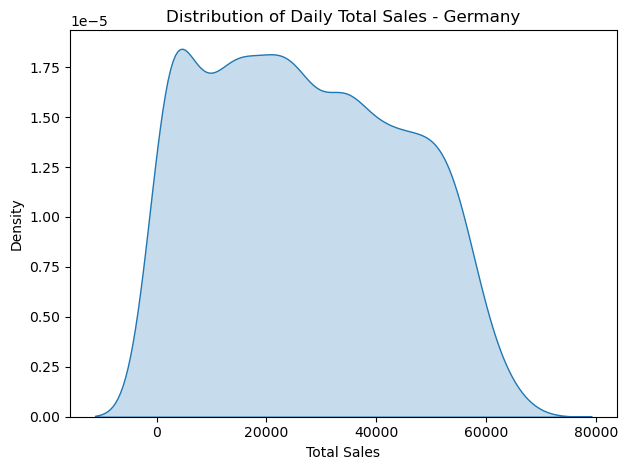

In [28]:
#b) 

#sales per order date
daily_sales = df_germany.groupby("OrderDate")["LineTotal"].sum().reset_index()
daily_sales.columns = ["OrderDate", "TotalSales"]

#plot 
sns.kdeplot(data = daily_sales, x = "TotalSales", fill = True)
plt.title("Distribution of Daily Total Sales - Germany")
plt.xlabel("Total Sales")
plt.ylabel("Density");
plt.tight_layout()

Revenue by Category Dataset


,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Condiments,55802774.45
2,Confections,66347544.94
3,Dairy Products,58034940.00
4,Grains/Cereals,28573512.55
5,Meat/Poultry,64896314.41
6,Produce,32706403.90
7,Seafood,49931965.52


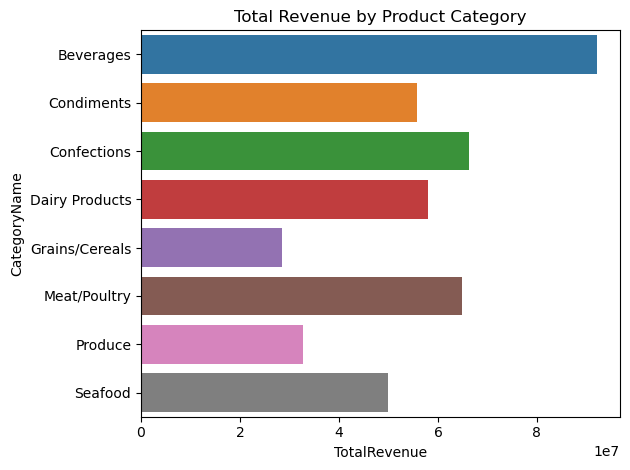

In [29]:
#c) New SQL query

connection = sqlite3.connect("northwind.db")
query3 = """
SELECT cat.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM 'Order Details' od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories cat ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName
"""

df_revenue = pd.read_sql_query(query3, connection)
connection.close()

print("Revenue by Category Dataset")
display(df_revenue)

#bar plot 
sns.barplot(data = df_revenue, x = "TotalRevenue", y = "CategoryName", hue = "CategoryName")
plt.title("Total Revenue by Product Category")
plt.xlabel("TotalRevenue")
plt.ylabel("CategoryName");
plt.tight_layout()

### Task 7: Comparing Python to SQL

In [31]:
#a) SQL query 

connection = sqlite3.connect("northwind.db")

query_products = "SELECT * FROM Products"
query_categories = "SELECT * FROM Categories"

df_products_full = pd.read_sql_query(query_products, connection)
df_categories_full = pd.read_sql_query(query_categories, connection)

print("Products table:")
display(df_products_full.head())
print("Categories table:")
display(df_categories_full.head())

Products table:


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


Categories table:


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [32]:
#b) inner join with python 

joinedpc = pd.merge(df_products_full, df_categories_full, how = "inner", on = "CategoryID")
display(joinedpc.head())

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [33]:
import time

#c) 
#timing SQL 

start_sql = time.time()

connection = sqlite3.connect("northwind.db")
query3 = """
SELECT cat.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM 'Order Details' od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories cat ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName
"""
df_sql = pd.read_sql_query(query3, connection)
end_sql = time.time()

print(f"SQL execution time: {end_sql - start_sql:.4f} seconds")

#timing Python Pandas
start_pandas = time.time()

df_orderdetails = pd.read_sql_query("SELECT * FROM 'Order Details'", connection)
df_products_full = pd.read_sql_query("SELECT * FROM Products", connection)
df_categories_full = pd.read_sql_query("SELECT * FROM Categories", connection)

merged = df_orderdetails.merge(df_products_full, on = "ProductID")
merged = merged.merge(df_categories_full, on = "CategoryID")

merged["LineTotal"] = merged["UnitPrice_x"] * merged["Quantity"]
df_pandas = merged.groupby("CategoryName")["LineTotal"].sum().reset_index()
df_pandas.columns = ["CategoryName", "TotalRevenue"]

end_pandas = time.time()

print(f"Pandas execution time: {end_pandas - start_pandas:.4f} seconds")

SQL execution time: 1.0978 seconds
Pandas execution time: 2.3677 seconds


The SQL execution time was over a second shorter than the Pandas execution time. This can also be seen from the amount of lines of code that the different executions require. The Python executions has more lines of code that performs different things wheras almost all of the work gets done in the SQL query. For this kind of requests it can be seen that it would be more efficient using SQL, also if the operations done are more requiring than this one it could probably lead to an even larger difference in execution time. 

### Task 8: Wide and Long Format

In [36]:
#Wide Data 
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

#Long Data 
long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})


#a) Convert Wide into Long 
print("a)")
wide_to_long = pd.melt(wide_data, id_vars = ["store"], value_vars = ["Q1_sales", "Q2_sales", "Q3_sales", "Q4_sales"],
                   var_name = "quarter", value_name = "sales")
display(wide_data)

#b) 
print("b)")
long_to_wide = long_data.pivot(
        index = "month", 
        columns = "product",
        values = "units_sold"
    ).rename_axis(columns = None).reset_index()
display(long_to_wide)


a)


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


b)


,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


In [37]:
#c) Converting back to original 
print("Wide to Long before Converting Back")
display(wide_to_long)
print("Long to Wide before Converting Back")
display(long_to_wide)

#converting back to wide
print("Wide Again")
wide = wide_to_long.pivot(index = "store", columns = "quarter", values = "sales").rename_axis(columns=None).reset_index()
display(wide)

#converting back to long
print("Long Again")
long = pd.melt(long_to_wide, id_vars = ["month"], value_vars = ["Laptop", "Phone"],
               var_name = "product", value_name = "units_sold")
display(long)


Wide to Long before Converting Back


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


Long to Wide before Converting Back


,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


Wide Again


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


Long Again


,month,product,units_sold
0,Feb,Laptop,50
1,Jan,Laptop,45
2,Mar,Laptop,55
3,Feb,Phone,110
4,Jan,Phone,120
5,Mar,Phone,130
